# Demonstration of the Project `c_space_viz`

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from mylib.robotViz import *
from mylib.Rectangle2D import *
from mylib.CSpaceViz import *
import os


In [78]:
# Create directories if they don't exist
if not os.path.exists('images'):
    os.makedirs('images')
if not os.path.exists('media'):
    os.makedirs('media')

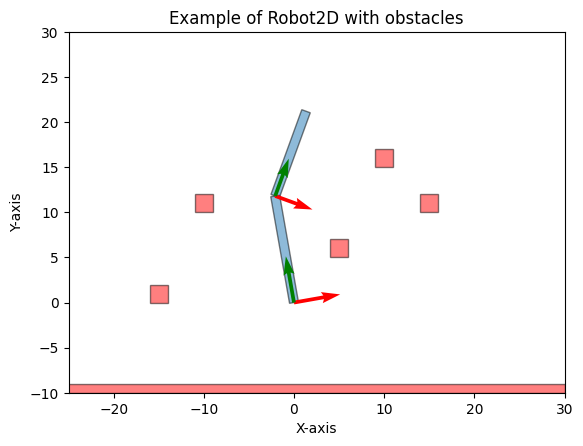

In [79]:
robot = Robot2D(world_frame=None)
robot.add_link(1, 12)
robot.add_link(1, 10)
configA = [10/180 * np.pi, -30/180 * np.pi]
configB = [-40/180 * np.pi, -160/180 * np.pi]
configC = [-80/180 * np.pi, 20/180 * np.pi]
configD = [60/180 * np.pi, 30/180 * np.pi]
configE = [1.5, -2.5]

ground = Obstacle2D(width=60, height=1, x = 0, y = -10)
obs1 = Obstacle2D(width=2, height=2, angle=0.0, x=5, y=5)
obs2 = Obstacle2D(2, 2, 0.0, 10, 15)
obs3 = Obstacle2D(2, 2, 0.0, 15, 10)
obs4 = Obstacle2D(2, 2, 0.0, -10, 10)
obs5 = Obstacle2D(2, 2, 0.0, -15, 0)
obstacles= [ground, obs1, obs2, obs3, obs4, obs5]

for i in range(2):
    robot.set_link_rotation(i,configA[i])
world = World2D(xlim=(-25, 30), ylim=(-10, 30))

for obs in obstacles:
    world.add_obstacle(obs)


world.add_robot(robot)
world.draw_world()
plt.title('Example of Robot2D with obstacles')
plt.savefig('images/robot2D.jpg')
plt.show()


## Robot in 2D space
We defined configuration A to D.\
Robot with each configuration is shown in this section.

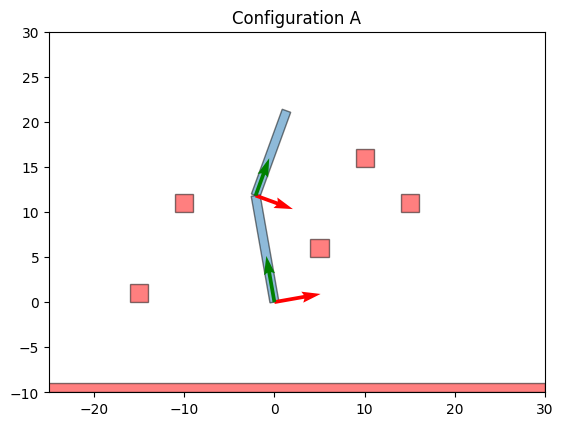

In [80]:
# show configuration A
plt.xlim(-25, 30)
plt.ylim(-10, 30)
plt.title('Configuration A')
robot.set_configuration(configA)
world.draw_world()

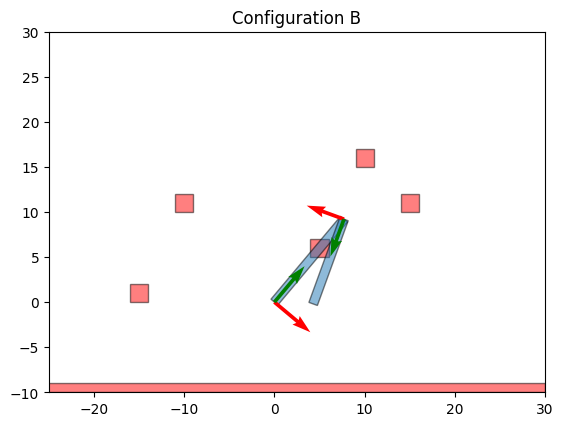

In [81]:
# show configuration B
plt.xlim(-25, 30)
plt.ylim(-10, 30)
plt.title('Configuration B')
robot.set_configuration(configB)
world.draw_world()

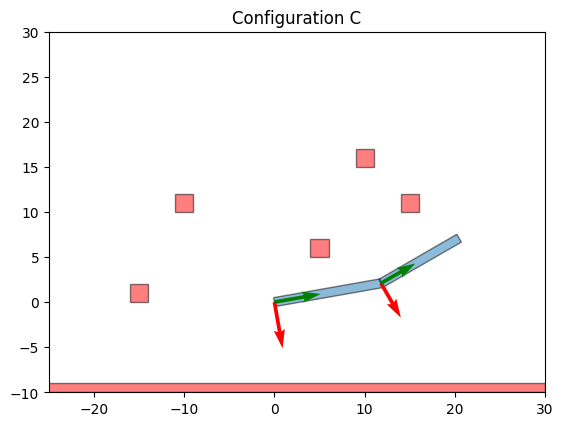

In [82]:
# show configuration C
plt.xlim(-25, 30)
plt.ylim(-10, 30)
plt.title('Configuration C')
robot.set_configuration(configC)
world.draw_world()

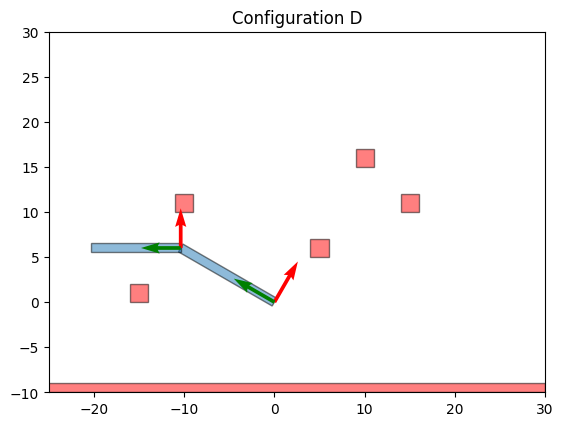

In [83]:
# show configuration D
plt.xlim(-25, 30)
plt.ylim(-10, 30)
plt.title('Configuration D')
robot.set_configuration(configD)
world.draw_world()

## Visualization of C-Space
We visualize the C-Space of this environment.\
Configuration B, which has collision with an obstacle, is plotted in the obstacle space.\
It is impossible to find a motion between two configuration such as configuration A and configuration C 
if they are not in the same continuous free space.\
Otherwise, there exists such a motion between two configurations (e.g. configuration A and configuration D)

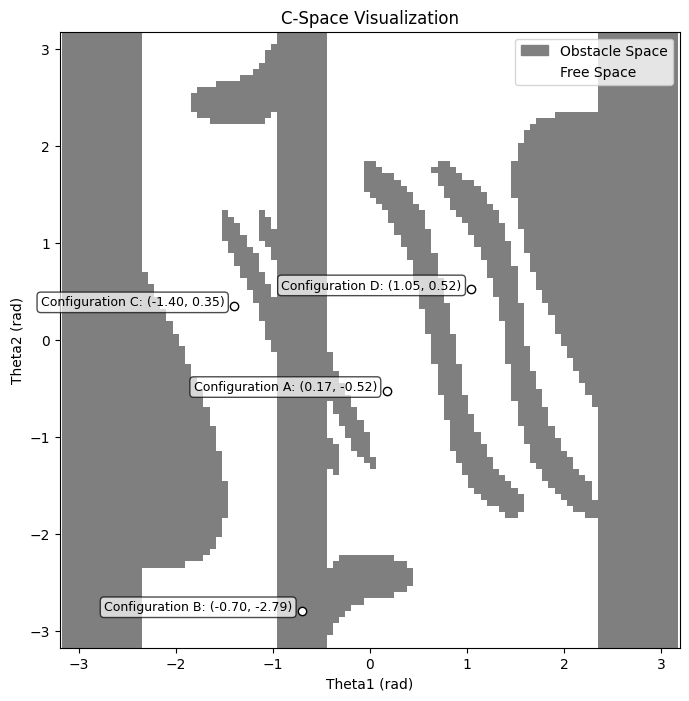

In [84]:
# Viszualize C-Space
cspaceViz = CSpaceViz2D(world=world)
cspaceViz.draw_cspace(n_samples=100) # change the parameter for better resolution
name_list = ['Configuration A', 'Configuration B', 'Configuration C', 'Configuration D']
for i, config in enumerate([configA, configB, configC, configD]):
    cspaceViz.plot_configuration(config[0], config[1], name=name_list[i])
plt.title('C-Space Visualization')
plt.savefig('images/cspace.jpg')
plt.show()


## Motion Planning

## RRT Planner
We use RRT planner to find a motion between two configurations.

In [85]:
from mylib.MotionPlanner import *
from mylib.graph2D import *
start = (configA[0], configA[1])
goal = (configD[0], configD[1])

step_size = 0.1
goal_bias = 0.05
# joint_limit = (-np.pi, 2)
rrt_planner = RRTPlanner2D(robot=robot, obstacles=obstacles, start=start, goal=goal, step_size=step_size, goal_bias=goal_bias)
path, cost = None, None
path, cost = rrt_planner.plan(6000)
# plt.figure(figsize=(8, 8))
G = rrt_planner.get_graph()
# G.draw_graph()
print(f'Graph size: {len(G.nodes)}')
if path is not None:
    print(f'cost: {cost}')
    print(f'n_points: {len(path)}')
    pathG = Graph2D(path=path)




Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4148
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4151
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4162
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4183
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4201
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4233
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4249
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4281
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4289
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4293
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4309
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4313
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 4314
Goal reached: (1.0471975511965976, 0.52359877559829

### RRT graph visualization
We visualize the RRT graph.\
The entire graph is shown in blue.\
The path from the start configuration to the goal configuration is shown in red.

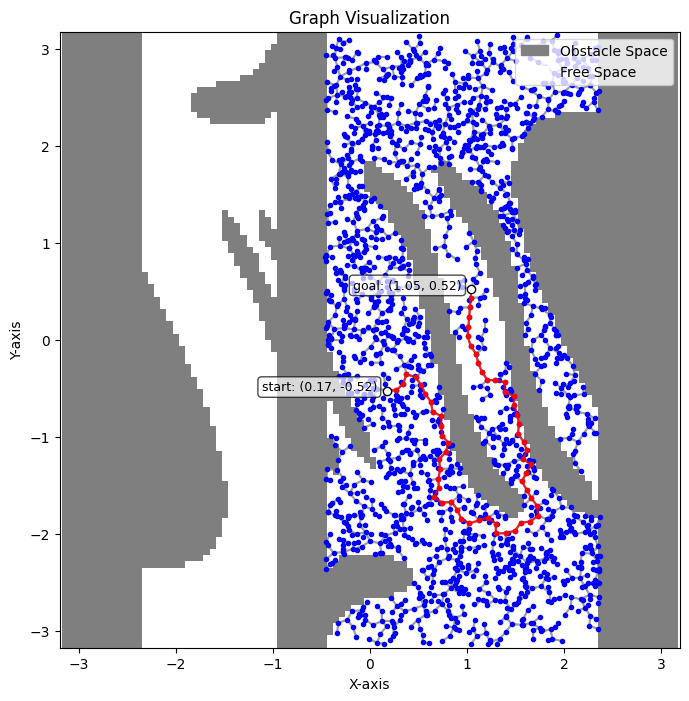

In [86]:
cspaceViz = CSpaceViz2D(world=world)

# Viszualize RRT in C-Space
cspaceViz.draw_cspace(n_samples=100) # change the parameter for better resolution
cspaceViz.draw_graph(G)
cspaceViz.draw_graph(pathG, node_color='red', edge_color='red')
cspaceViz.plot_configuration(start[0], start[1], name='start')
cspaceViz.plot_configuration(goal[0], goal[1], name='goal')
plt.savefig('images/rrt_graph.jpg', format='jpg', dpi=300)
plt.show()


### Motion Visualization Planned by RRT Algorithm
We visualize the motion planned by RRT algorithm.

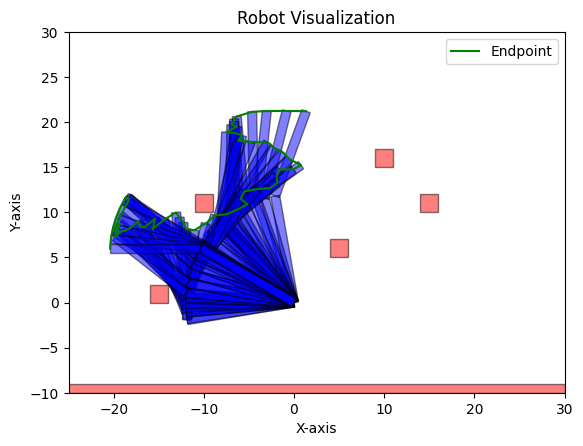

In [87]:
# Robot in 2D space following the motion planned by RRT algorithm
# Picture Output
fig, ax = world.show_after_image(path=path)
ax.legend()
fig.savefig('images/rrt_after_image.jpg', format='jpg')

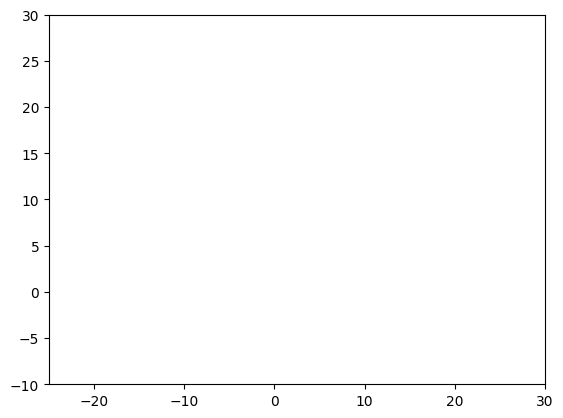

In [88]:
# Gif Output
# Animate the path planned by RRT algorithm
ani = world.animate(path)
ani.save("media/rrt_animation.gif", writer='pillow')  # Out put can be seen in media folder

## EST Planner
We use EST planner to find a motion between two configurations.


In [89]:
step_size = 0.2
goal_bias = 0.05
est_planner = ESTPlanner2D(robot=robot, obstacles=obstacles, start=start, goal=goal, step_size=step_size, goal_bias=goal_bias)
path2, cost2 = None, None
path2, cost2 = est_planner.plan(2500)

G2 = est_planner.get_graph()

print(f'Graph size: {len(G2.nodes)}')
if path2 is not None:
    print(f'cost: {cost2}')
    print(f'n_points: {len(path2)}')
    pathG2 = Graph2D(path=path2)


Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2093
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2104
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2118
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2151
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2158
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2259
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2301
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2316
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2329
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2428
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2429
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2470
Goal reached: (1.0471975511965976, 0.5235987755982988) at iteration 2491
Graph size: 2455
cost: 7.4224098391261135
n_points:

#### EST graph visualization
We visualize the EST graph.\
The entire graph is shown in blue.\
The path from the start configuration to the goal configuration is shown in red.


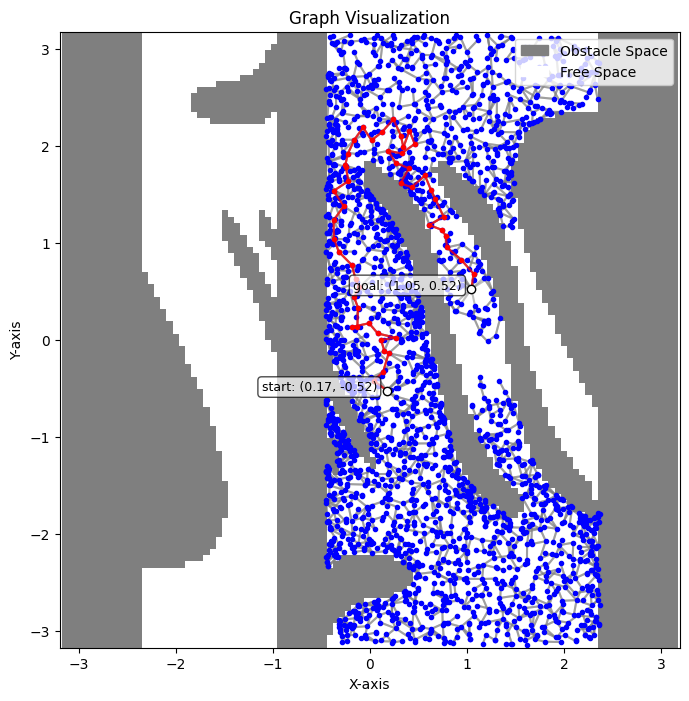

In [90]:
# Visualize EST in C-space
cspaceViz.draw_cspace(n_samples=100) # change the parameter for better resolution
cspaceViz.draw_graph(G2)
cspaceViz.draw_graph(pathG2, node_color='red', edge_color='red')
cspaceViz.plot_configuration(start[0], start[1], name='start')
cspaceViz.plot_configuration(goal[0], goal[1], name='goal')
plt.savefig('images/est_graph.jpg', format='jpg', dpi=300)
plt.show()


### Motion Visualization Planned by EST Algorithm
We visualize the motion planned by EST algorithm.

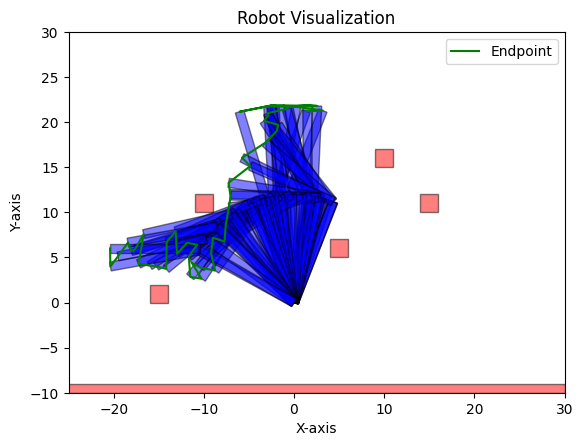

In [91]:
# Robot in 2D space following the motion planned by EST algorithm
# Picture Output
fig, ax = world.show_after_image(path=path2)
ax.legend()
fig.savefig('images/est_after_image.jpg', format='jpg')

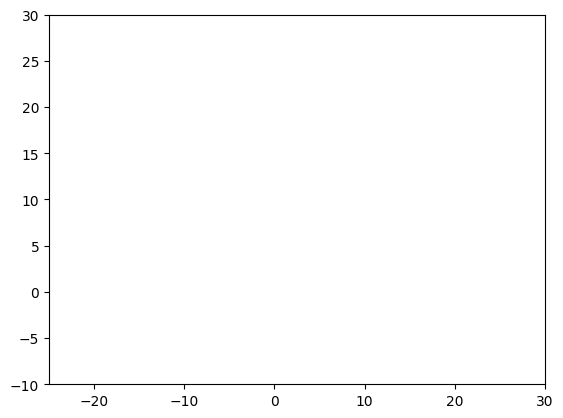

In [92]:
# Gif Output
# Animate the path planned by EST algorithm
ani = world.animate(path2)
ani.save("media/rrt_animation.gif", writer='pillow')  # Out put can be seen in media folder

## PRM Planner
We use PRM planner to find a motion between two configurations.

In [93]:
k_nearest = 5
prm_planner = PRMPlanner2D(robot=robot, obstacles=obstacles, start=start, goal=goal, k_nearest=k_nearest)
path3, cost3 = None, None
path3, cost3 = prm_planner.plan(1500)

G3 = prm_planner.get_graph()

print(f'Graph size: {len(G3.nodes)}')
if path3 is not None:
    print(f'cost: {cost3}')
    print(f'n_points: {len(path3)}')
    pathG3 = Graph2D(path=path3)

Graph size: 1502
cost: 4.892311352964623
n_points: 43


#### PRM graph visualization
We visualize the PRM graph.\
The entire graph is shown in blue.\
The path from the start configuration to the goal configuration is shown in red.


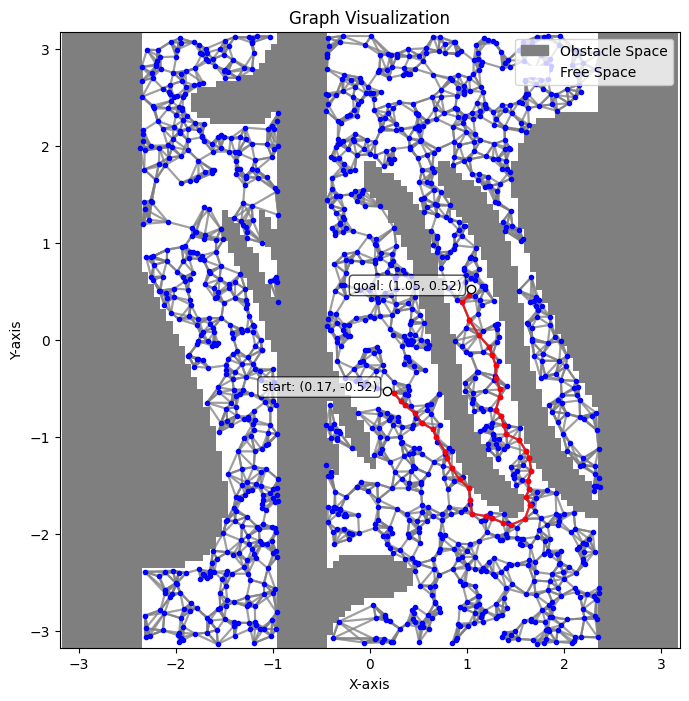

In [94]:
# Visualize PRM in C-space
cspaceViz.draw_cspace(n_samples=100) # change the parameter for better resolution
cspaceViz.draw_graph(G3)
cspaceViz.draw_graph(pathG3, node_color='red', edge_color='red')
cspaceViz.plot_configuration(start[0], start[1], name='start')
cspaceViz.plot_configuration(goal[0], goal[1], name='goal')
plt.savefig('images/prm_graph.jpg', format='jpg', dpi=300)
plt.show()

### Motion Visualization Planned by PRM Algorithm
We visualize the motion planned by PRM algorithm.

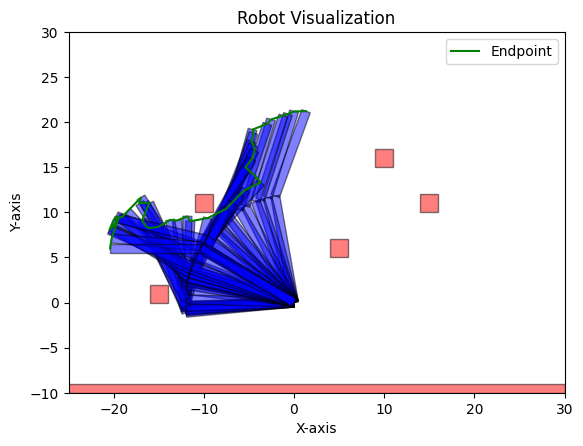

In [95]:
# Robot in 2D space following the motion planned by EST algorithm
# Picture Output
fig, ax = world.show_after_image(path=path3)
ax.legend()
fig.savefig('images/prm_after_image.jpg', format='jpg')

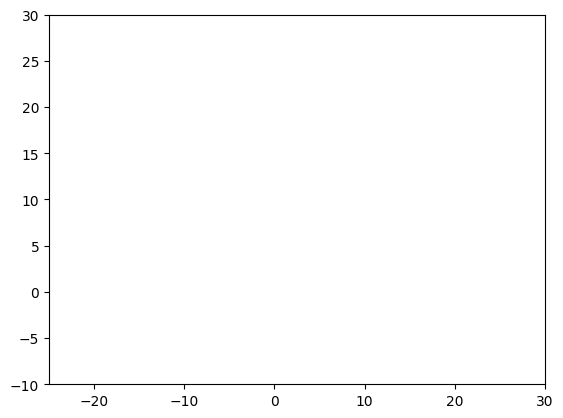

In [96]:
# Gif Output
# Animate the path planned by PRM algorithm
ani = world.animate(path3)
ani.save("media/prm_animation.gif", writer='pillow')  # for gif
